This document analyzes the dataset logged by CARLA's system. The metrics to be measured are the following: 
1. **Reaction Time**
    - This is from the time the alert was sent until the time the driver made an action. This will help the researches know the appropriate time to give an alert. 
2. **Completion Time**
    - This measures the duration of the whole violation. From the alert being triggered until the speeding gets resolved. 
3. **Ignored Alert** 
    - This checks whether the driver made an action to the alert or ignored it. This will be used to prove the effectiveness of providing an alert to decrease speed.
4. **Speed Change**
    - This checks the speed. 
5. **Alert Effectiveness**
    - This computes for the number of resolved speeding violations, where the rider either *reduced throttle* or *brakes* which is then divided by all violations. (resolved/all violations) 

*Note: An action made by the driver can be either a release of the throttle or pressing on the brakes.* 

In [58]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import chi2_contingency
from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_rel
import matplotlib.patches as mpatches


In [59]:
df = pd.read_csv("cleaned_Sim.csv")

df.head()


,timestamp,participant_no,phase,scenario,speed_kmh,event,details,speed_limit,Location_X,Location_Y,overspeed,reduce_throttle,resolved,event_id,nearest_idx,distance_sq,on_route
0,1.771924e+09,17,4,WEBSOCKET,0.71,WS_SEND,"{""phase"": 4, ""speed"": 0.71, ""speed_limit"": 30,...",30.0,NaN,NaN,False,False,False,0,-1,inf,False
1,1.771924e+09,17,4,WEBSOCKET,0.71,WS_SEND,"{""phase"": 4, ""speed"": 0.71, ""speed_limit"": 30,...",30.0,NaN,NaN,False,False,False,0,-1,inf,False
2,1.771924e+09,17,4,WEBSOCKET,0.71,WS_SEND,"{""phase"": 4, ""speed"": 0.71, ""speed_limit"": 30,...",30.0,NaN,NaN,False,False,False,0,-1,inf,False
3,1.771924e+09,17,4,WEBSOCKET,1.17,WS_SEND,"{""phase"": 4, ""speed"": 1.17, ""speed_limit"": 30,...",30.0,NaN,NaN,False,False,False,0,-1,inf,False
4,1.771924e+09,17,4,WEBSOCKET,1.19,WS_SEND,"{""phase"": 4, ""speed"": 1.19, ""speed_limit"": 30,...",30.0,NaN,NaN,False,False,False,0,-1,inf,False


In [60]:
df.columns

Index(['timestamp', 'participant_no', 'phase', 'scenario', 'speed_kmh',
       'event', 'details', 'speed_limit', 'Location_X', 'Location_Y',
       'overspeed', 'reduce_throttle', 'resolved', 'event_id', 'nearest_idx',
       'distance_sq', 'on_route'],
      dtype='object')

In [61]:
df["scenario"].unique()

array(['WEBSOCKET', 'TRAFFIC_LIGHT', 'SPEED_LIMIT', 'STOP'], dtype=object)

In [62]:
df["details"].str.contains("TrafficLight", na=False).sum()

276

In [63]:
df.loc[
    (df["event_id"]==45),
    ["speed_kmh", "scenario", "speed_limit", "details", "event_id"]
]

,speed_kmh,scenario,speed_limit,details,event_id
77952,37.25,WEBSOCKET,30.0,"{""phase"": 3, ""speed"": 37.25, ""speed_limit"": 30...",45
77953,37.55,WEBSOCKET,30.0,"{""phase"": 3, ""speed"": 37.55, ""speed_limit"": 30...",45
77954,38.12,WEBSOCKET,30.0,"{""phase"": 3, ""speed"": 38.12, ""speed_limit"": 30...",45
77955,38.12,WEBSOCKET,30.0,"{""phase"": 3, ""speed"": 38.12, ""speed_limit"": 30...",45
77956,38.12,WEBSOCKET,30.0,"{""phase"": 3, ""speed"": 38.12, ""speed_limit"": 30...",45
77957,38.52,WEBSOCKET,30.0,"{""phase"": 3, ""speed"": 38.52, ""speed_limit"": 30...",45
77958,39.81,WEBSOCKET,30.0,"{""phase"": 3, ""speed"": 39.81, ""speed_limit"": 30...",45
77959,40.03,WEBSOCKET,30.0,"{""phase"": 3, ""speed"": 40.03, ""speed_limit"": 30...",45
77960,40.03,WEBSOCKET,30.0,"{""phase"": 3, ""speed"": 40.03, ""speed_limit"": 30...",45
77961,40.03,WEBSOCKET,30.0,"{""phase"": 3, ""speed"": 40.03, ""speed_limit"": 30...",45


In [64]:
df["event"].unique()

array(['WS_SEND', 'YELLOW_LIGHT_PASS', 'REACTION', 'SPEED_VIOLATION',
       'RED_LIGHT_VIOLATION', 'PHASE_STOP'], dtype=object)

In [65]:
df.loc[
    (df["participant_no"] == 5) & (df["event"]=="RED_LIGHT_VIOLATION"),
    ["participant_no", "phase", "speed_kmh", "scenario", "details", "event_id"]
]

,participant_no,phase,speed_kmh,scenario,details,event_id
211449,5,4,19.74,TRAFFIC_LIGHT,TrafficLight Violation at Location(x=-20.03606...,0
212071,5,4,21.02,TRAFFIC_LIGHT,TrafficLight Violation at Location(x=134.17388...,0
212799,5,4,8.15,TRAFFIC_LIGHT,TrafficLight Violation at Location(x=230.82778...,0
213824,5,4,7.24,TRAFFIC_LIGHT,TrafficLight Violation at Location(x=22.778585...,0
215284,5,4,7.86,TRAFFIC_LIGHT,TrafficLight Violation at Location(x=-144.5323...,0
215430,5,4,26.32,TRAFFIC_LIGHT,TrafficLight Violation at Location(x=-131.9122...,0
215440,5,4,29.22,TRAFFIC_LIGHT,TrafficLight Violation at Location(x=-128.6030...,0
215624,5,4,7.44,TRAFFIC_LIGHT,TrafficLight Violation at Location(x=-101.6513...,0
216504,5,4,16.65,TRAFFIC_LIGHT,TrafficLight Violation at Location(x=-19.43998...,0
216890,5,1,10.07,TRAFFIC_LIGHT,TrafficLight Violation at Location(x=-61.08915...,0


In [66]:
df.loc[df["speed_limit"] == 60, "event_id"].unique()

array([  5,   0,  29,  51, 122, 136, 183, 235, 250, 270, 289, 290, 291,
       292, 301, 332, 412, 422, 432, 522, 532])

## Metrics Computation & Analysis

In [67]:
df_Metrics = df.copy()

### Reaction Time

*action=REDUCE_THROTTLE* is a signal that the driver released yung tapak niya sa pedal. 

In [68]:
df.loc[
    df["event_id"].isin([9]),
    ["phase","speed_kmh", "scenario", "speed_limit", "details", "event_id"]
]

,phase,speed_kmh,scenario,speed_limit,details,event_id
15607,2,40.00,SPEED_LIMIT,NaN,action=REDUCE_THROTTLE|time=0.52s|control={'th...,9
15608,2,40.10,SPEED_LIMIT,30.0,Speed 40.10 km/h > limit 30.00 km/h at Locatio...,9
15609,2,36.87,SPEED_LIMIT,NaN,action=VIOLATION_RESOLVED|time=0.99s|reaction_...,9


In [69]:
df_Metrics["carla_reaction_time"] = (
    df_Metrics.loc[df_Metrics["scenario"] == "SPEED_LIMIT", "details"]
    .str.extract(r"action=REDUCE_THROTTLE\|time=(\d+\.\d+)s")
    .astype(float)
)

In [70]:
carla_reactions = df_Metrics.loc[
    df_Metrics["carla_reaction_time"].notna(),
    ["event_id", "carla_reaction_time"]
]

In [71]:
display(carla_reactions.head(5))

,event_id,carla_reaction_time
767,1,0.76
5496,2,1.86
6252,3,0.76
7122,4,0.21
15598,7,1.92


*Note: in the cases of NaN values: at times the rider is just above the speeding threshold, the system in CARLA might not have detected enough throttle release. Therefore, in the subtracting the action to the start becomes not applicable.*

### Completion Time

In [72]:
df_Metrics["carla_completion_time"] = df_Metrics["details"].str.extract(
    r"action=VIOLATION_RESOLVED\|time=(\d+\.\d+)s"
).astype(float)

In [73]:
carla_complete = df_Metrics.loc[
    df_Metrics["carla_completion_time"].notna(),
    ["event_id", "carla_completion_time"]
]

In [74]:
display(carla_complete.tail(10))

,event_id,carla_completion_time
348702,0,0.15
349962,534,0.49
350409,535,3.98
351085,536,0.22
351980,537,2.39
352149,538,0.29
352709,539,1.77
353765,540,3.45
355066,541,1.91
356023,542,1.77


### Ignored Alert

In [75]:
df_Metrics["alert_ignored"] = (df_Metrics["carla_reaction_time"] >= 2.5).fillna(0).astype(int)

In [76]:
ignore = df_Metrics.loc[
    df_Metrics["carla_reaction_time"].notna(),  # only rows with reaction time
    ["event_id", "carla_reaction_time", "alert_ignored"]  # columns to display
]

ignore.tail(10)

,event_id,carla_reaction_time,alert_ignored
348692,532,0.24,0
348698,533,0.57,0
349958,534,0.37,0
350380,535,2.55,1
351948,537,0.82,0
352144,538,0.12,0
352690,539,0.89,0
353744,540,2.47,0
355047,541,1.03,0
356003,542,0.87,0


### Alert Effectiveness

In [77]:
speedingCount = df_Metrics["details"].str.contains("VIOLATION_RESOLVED", na=False).sum() # dapat not ignored to
unignored = (carla_reactions["carla_reaction_time"] < 2.5).sum()
ignored = (carla_reactions["carla_reaction_time"] >= 2.5).sum()
valid_reactions = (carla_reactions["carla_reaction_time"]).notna().sum()
valid_complete = (carla_complete["carla_completion_time"].notna().sum())

In [78]:
total_effective = unignored/speedingCount

In [79]:
print("Unignored Count: ", unignored)
print("Ignored Count: ", ignored)
print("Supposed Total events: ", unignored + ignored)
print("Reaction Time: ", valid_reactions)
print("Completion Time: ", valid_complete)
print("Total resolved violations: ", speedingCount)
print(f"Effectiveness: {total_effective*100:.4f}%")

Unignored Count:  435
Ignored Count:  29
Supposed Total events:  464
Reaction Time:  464
Completion Time:  601
Total resolved violations:  601
Effectiveness: 72.3794%


In [80]:
ignored_result=(ignored / df_Metrics["event_id"].nunique())

In [81]:
print(f"Ignored alerts: {ignored_result* 100:.4f}%")

Ignored alerts: 5.3407%


In [82]:
summary_table = pd.DataFrame({
    "Mean": [
        carla_complete["carla_completion_time"].mean(),
        carla_reactions["carla_reaction_time"].mean()
    ],
    "Median": [
        carla_complete["carla_completion_time"].median(),
        carla_reactions["carla_reaction_time"].median()
    ],
    "Std Dev": [
        carla_complete["carla_completion_time"].std(),
        carla_reactions["carla_reaction_time"].std()
    ]
},
index=[
    "Completion Time",
    "Reaction Time"
])

print(summary_table)

                     Mean  Median   Std Dev
Completion Time  2.499850   1.710  2.596440
Reaction Time    1.061595   0.835  0.766071


## Alert-Phase Analysis

| Metric                     | Why                             |
| -------------------------- | ------------------------------- |
| Mean Reaction Time         | how quickly riders respond      |
| SD Reaction Time           | variability                     |
| Mean Completion Time       | how fast violation is corrected |
| Ignored Alert Rate         | how often alerts are ignored    |



In [83]:
results = []

for phase, df_phase in df_Metrics.groupby("phase"):

    n_events = df_phase["carla_reaction_time"].notna().sum()

    reactions = df_phase["carla_reaction_time"].dropna()
    mean_reaction = reactions.mean()
    median_reactions = reactions.median()
    sd_reaction = reactions.std()

    results.append({
        "Phase": phase,
        "n_events": n_events,
        "Mean ReactionT": mean_reaction,
        "Median ReactionT": median_reactions,
        "SD ReactionT": sd_reaction
    })

metrics_table = pd.DataFrame(results).sort_values("Phase")
display(metrics_table)

,Phase,n_events,Mean ReactionT,Median ReactionT,SD ReactionT
0,1,112,1.179821,1.04,0.776053
1,2,90,1.145333,0.94,0.821778
2,3,146,0.964932,0.75,0.747430
3,4,116,1.004138,0.78,0.721209


In [84]:
results = []

for phase, df_phase in df_Metrics.groupby("phase"):

    n_events = df_phase["details"].str.contains("VIOLATION_RESOLVED", na=False).sum()

    complete = df_phase["carla_completion_time"].dropna()
    mean_complete = complete.mean()
    sd_complete = complete.std()

    total_violations = n_events
    unignored = (df_phase["carla_reaction_time"] < 2.5).sum()

    ignored_percent = ((total_violations - unignored) / total_violations) * 100 if total_violations > 0 else 0
    effectiveness = (unignored / total_violations)*100 if total_violations > 0 else 0

    results.append({
        "Phase": phase,
        "n_events": n_events,
        "Mean Complete": mean_complete,
        "STD Complete" : sd_complete,
        "Ignored %": ignored_percent,
        "Effectiveness": effectiveness
    })

metrics_table = pd.DataFrame(results).sort_values("Phase")
display(metrics_table)

,Phase,n_events,Mean Complete,STD Complete,Ignored %,Effectiveness
0,1,156,2.731410,2.325275,32.692308,67.307692
1,2,122,2.893689,3.308951,32.786885,67.213115
2,3,182,2.117088,2.194470,24.725275,75.274725
3,4,141,2.396950,2.611643,21.276596,78.723404


## new changes 

### Baseline
- compute individually for the speeding violations
- compute reaction time and completion time - joke di to need kasi walang alerts 

In [85]:
df_phase1 = df_Metrics[df_Metrics["phase"] == 1]

In [86]:
violations = df_phase1["event"].str.contains("SPEED", na=False)
speed_counts = (
    df_phase1[violations]
    .groupby("participant_no")
    .size()
)
speed_counts = speed_counts.reindex(range(1, 21), fill_value=0)

In [87]:
display(speed_counts)

participant_no
1     21
2      2
3     15
4     11
5      7
6      2
7      1
8      3
9     14
10     4
11     7
12    20
13     1
14     6
15    11
16     2
17     2
18     7
19    16
20     4
dtype: int64

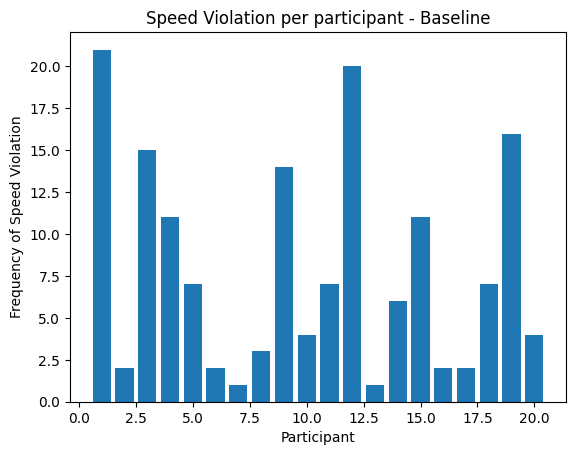

In [88]:
plt.bar(speed_counts.index, speed_counts.values)
plt.xlabel("Participant")
plt.ylabel("Frequency of Speed Violation")
plt.title("Speed Violation per participant - Baseline")
plt.show()

### Audio Only

In [89]:
df_phase2 = df_Metrics[df_Metrics["phase"] == 2]

In [90]:
violations = df_phase2["event"].str.contains("SPEED", na=False)
speed_counts2 = (
    df_phase2[violations]
    .groupby("participant_no")
    .size()
)
speed_counts2 = speed_counts2.reindex(range(1, 21), fill_value=0)

In [91]:
display(speed_counts2)

participant_no
1      3
2      1
3      2
4      8
5      8
6      3
7      1
8     13
9     10
10     9
11     4
12    18
13     4
14     2
15    12
16     0
17     3
18     4
19    13
20     4
dtype: int64

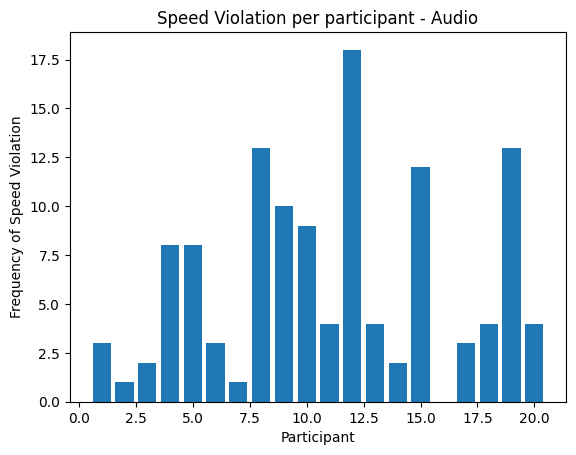

In [92]:
plt.bar(speed_counts2.index, speed_counts2.values)
plt.xlabel("Participant")
plt.ylabel("Frequency of Speed Violation")
plt.title("Speed Violation per participant - Audio")
plt.show()

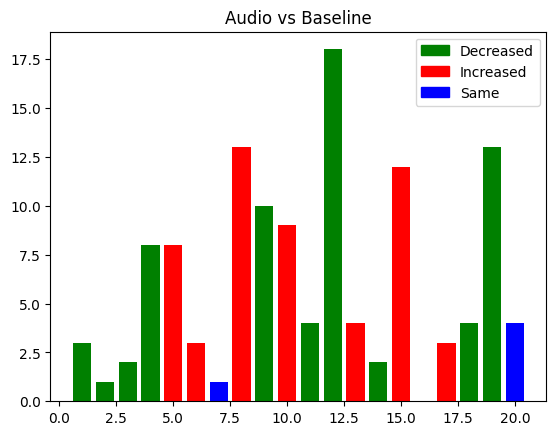

In [93]:
colors = [
    'green' if a < b else 'red' if a > b else 'blue'
    for a, b in zip(speed_counts2, speed_counts)
]
plt.bar(speed_counts2.index,  speed_counts2.values, color=colors)

green_patch = mpatches.Patch(color='green', label='Decreased')
red_patch = mpatches.Patch(color='red', label='Increased')
blue_patch = mpatches.Patch(color='blue', label='Same')

plt.legend(handles=[green_patch, red_patch, blue_patch])

plt.bar(speed_counts2.index,  speed_counts2.values, color=colors)
plt.title("Audio vs Baseline")
plt.show()

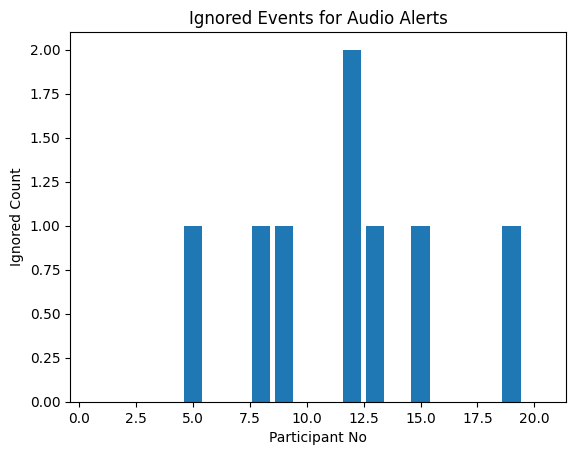

In [94]:
ignored = df_phase2["alert_ignored"]==1
ignored_counts2 = (
    df_phase2[ignored]
    .groupby("participant_no")
    .size()
)
ignored_counts2 = ignored_counts2.reindex(range(1, 21), fill_value=0)

plt.bar(ignored_counts2.index, ignored_counts2.values)

plt.xlabel("Participant No")
plt.ylabel("Ignored Count")
plt.title("Ignored Events for Audio Alerts")

plt.show()

### Haptic Only

In [95]:
df_phase3 = df_Metrics[df_Metrics["phase"] == 3]

In [96]:
violations = df_phase3["event"].str.contains("SPEED", na=False)
speed_counts3 = (
    df_phase3[violations]
    .groupby("participant_no")
    .size()
)
speed_counts3 = speed_counts3.reindex(range(1, 21), fill_value=0)

In [97]:
print(speed_counts3)

participant_no
1      8
2      1
3      7
4     20
5      5
6      3
7      2
8      0
9     21
10    15
11     9
12    25
13     3
14     4
15    18
16     1
17     2
18     9
19    23
20     6
dtype: int64


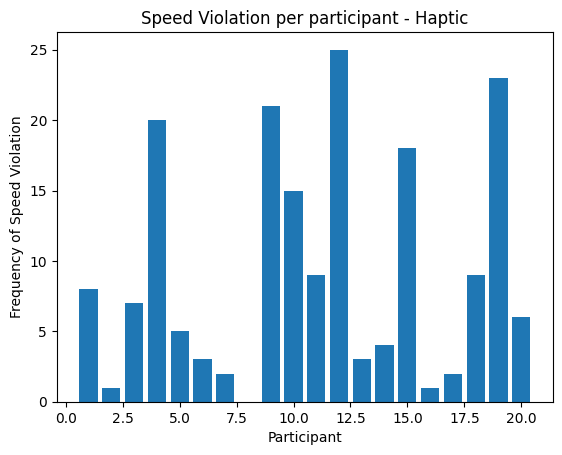

In [98]:
plt.bar(speed_counts3.index, speed_counts3.values)
plt.xlabel("Participant")
plt.ylabel("Frequency of Speed Violation")
plt.title("Speed Violation per participant - Haptic")
plt.show()

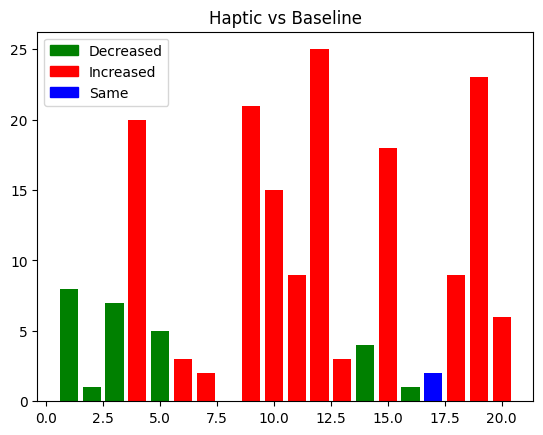

In [99]:
colors = [
    'green' if a < b else 'red' if a > b else 'blue'
    for a, b in zip(speed_counts3, speed_counts)
]

plt.bar(speed_counts3.index, speed_counts3.values, color=colors)

green_patch = mpatches.Patch(color='green', label='Decreased')
red_patch = mpatches.Patch(color='red', label='Increased')
blue_patch = mpatches.Patch(color='blue', label='Same')

plt.legend(handles=[green_patch, red_patch, blue_patch])
plt.title("Haptic vs Baseline")
plt.show()

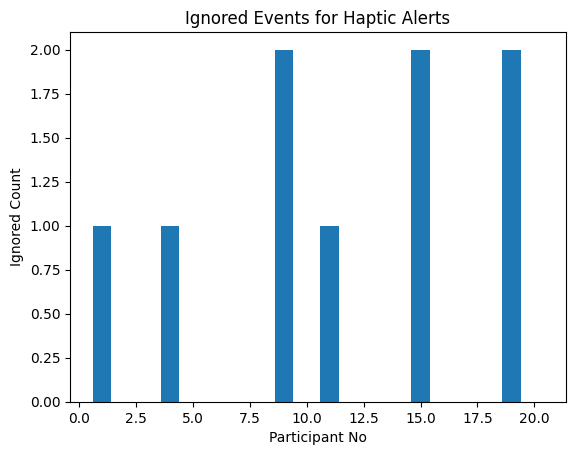

In [100]:
ignored = df_phase3["alert_ignored"]==1
ignored_counts3 = (
    df_phase3[ignored]
    .groupby("participant_no")
    .size()
)
ignored_counts3 = ignored_counts3.reindex(range(1, 21), fill_value=0)

plt.bar(ignored_counts3.index, ignored_counts3.values)

plt.xlabel("Participant No")
plt.ylabel("Ignored Count")
plt.title("Ignored Events for Haptic Alerts")

plt.show()

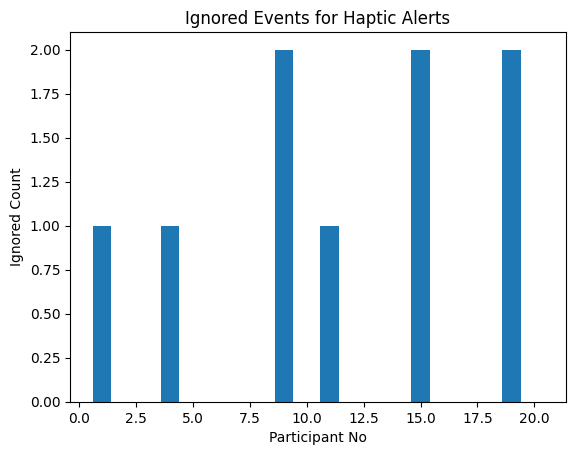

In [101]:
plt.bar(ignored_counts3.index, ignored_counts3.values)

plt.xlabel("Participant No")
plt.ylabel("Ignored Count")
plt.title("Ignored Events for Haptic Alerts")

plt.show()

### Combined

In [102]:
df_phase4 = df_Metrics[df_Metrics["phase"] == 4]
df_phase4.columns

Index(['timestamp', 'participant_no', 'phase', 'scenario', 'speed_kmh',
       'event', 'details', 'speed_limit', 'Location_X', 'Location_Y',
       'overspeed', 'reduce_throttle', 'resolved', 'event_id', 'nearest_idx',
       'distance_sq', 'on_route', 'carla_reaction_time',
       'carla_completion_time', 'alert_ignored'],
      dtype='object')

In [103]:
violations = df_phase4["event"].str.contains("SPEED", na=False)
speed_counts4 = (
    df_phase4[violations]
    .groupby("participant_no")
    .size()
)
speed_counts4 = speed_counts4.reindex(range(1, 21), fill_value=0)

In [104]:
display(speed_counts4)

participant_no
1     13
2      0
3     12
4     18
5      9
6      5
7      1
8      8
9      0
10     2
11     5
12    14
13     3
14     5
15     0
16     5
17     3
18    17
19    17
20     5
dtype: int64

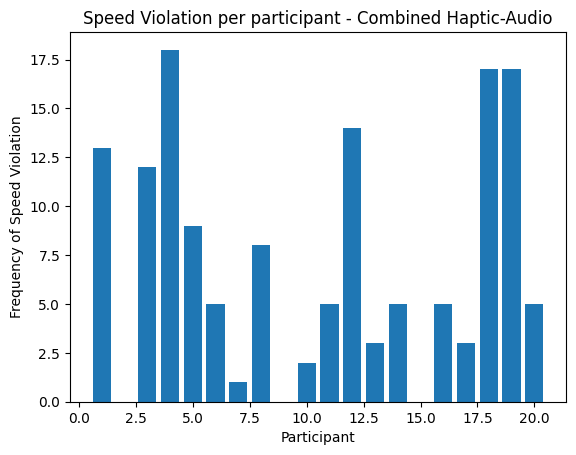

In [105]:
plt.bar(speed_counts4.index, speed_counts4.values)
plt.xlabel("Participant")
plt.ylabel("Frequency of Speed Violation")
plt.title("Speed Violation per participant - Combined Haptic-Audio")
plt.show()

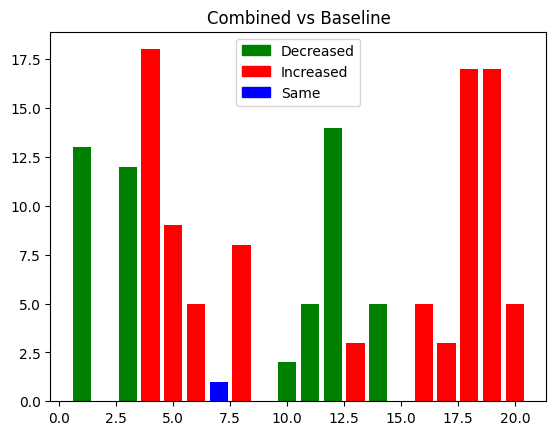

In [106]:
colors = [
    'green' if a < b else 'red' if a > b else 'blue'
    for a, b in zip(speed_counts4, speed_counts)
]

plt.bar(speed_counts4.index, speed_counts4.values, color=colors)

green_patch = mpatches.Patch(color='green', label='Decreased')
red_patch = mpatches.Patch(color='red', label='Increased')
blue_patch = mpatches.Patch(color='blue', label='Same')

plt.legend(handles=[green_patch, red_patch, blue_patch])
plt.title("Combined vs Baseline")
plt.show()

In [107]:
ignored = df_phase4["alert_ignored"]==1
ignored_counts4 = (
    df_phase4[ignored]
    .groupby("participant_no")
    .size()
)
ignored_counts4 = ignored_counts4.reindex(range(1, 21), fill_value=0)

In [108]:
display(ignored_counts4)

participant_no
1     0
2     0
3     0
4     2
5     0
6     1
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    1
19    1
20    0
dtype: int64

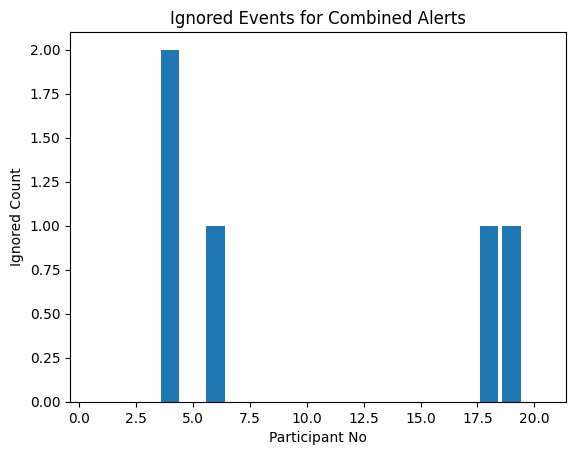

In [109]:
plt.bar(ignored_counts4.index, ignored_counts4.values)

plt.xlabel("Participant No")
plt.ylabel("Ignored Count")
plt.title("Ignored Events for Combined Alerts")

plt.show()

In [129]:
df_Metrics["event"].unique()

array(['WS_SEND', 'YELLOW_LIGHT_PASS', 'REACTION', 'SPEED_VIOLATION',
       'RED_LIGHT_VIOLATION', 'PHASE_STOP'], dtype=object)

In [132]:
mostViolation = (
    df_Metrics[df_Metrics["event"] == "SPEED_VIOLATION"]
    .groupby("phase")
    .size()
)

display(mostViolation)

phase
1    156
2    122
3    182
4    142
dtype: int64

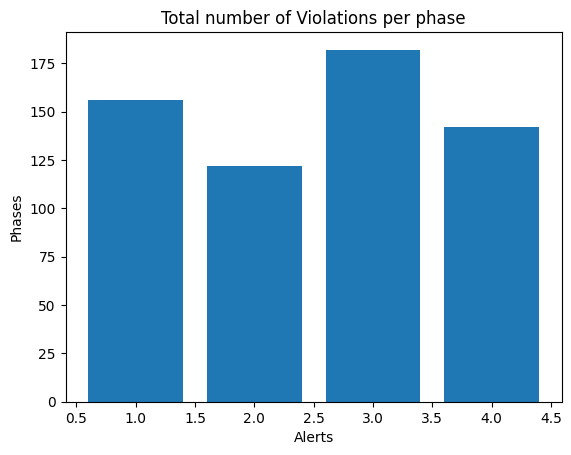

In [135]:
plt.bar(mostViolation.index, mostViolation.values)

plt.xlabel("Alerts")
plt.ylabel("Phases")
plt.title("Total number of Violations per phase")

plt.show()

### Means per participant

In [110]:
mean_rt_4 = df_phase4.groupby("participant_no")["carla_reaction_time"].mean()
mean_rt_4 = mean_rt_4.reindex(range(1, 21), fill_value=0)
print(mean_rt_4)

participant_no
1     0.807778
2          NaN
3     0.956000
4     1.253750
5     0.616250
6     1.310000
7          NaN
8     0.575714
9     0.000000
10    0.360000
11    0.860000
12    1.604286
13    1.335000
14    0.396000
15    0.000000
16    0.387500
17    1.126667
18    0.972667
19    1.150909
20    0.766667
Name: carla_reaction_time, dtype: float64


## other parts na 

In [112]:
alerts = df_Metrics[df_Metrics["carla_reaction_time"].notna()]

ignored_alerts = (alerts["carla_reaction_time"] >= 2.5).sum()

overall_ignored_percent = ignored_alerts / len(alerts) * 100

print(f"Overall ignored alerts: {overall_ignored_percent:.2f}%")

Overall ignored alerts: 6.25%


In [113]:
# collapse to one row per event
alerts = df_Metrics.groupby("event_id").agg({
    "phase": "first",           # each event belongs to one phase
    "alert_ignored": "max"      # if any frame was ignored, mark the event as ignored
}).reset_index()

# now build the correct contingency table
contingency_table = pd.crosstab(alerts["phase"], alerts["alert_ignored"])
print(contingency_table)

alert_ignored    0  1
phase                
1              105  7
2              111  8
3              163  9
4              135  5


## STOPLIGHT

In [114]:
results = []

for phase, df_phase in df.groupby("phase"):

    # total traffic lights encountered
    lights_encountered = df_phase["scenario"].eq("TRAFFIC_LIGHT").sum()

    # red light violations
    violations = df_phase["event"].str.contains("RED_LIGHT_VIOLATION", na=False).sum()

    # compliance rate
    compliance_rate = ((lights_encountered - violations) / lights_encountered) if lights_encountered > 0 else 0

    results.append({
        "Phase": phase,
        "Traffic Lights Encountered": lights_encountered,
        "Violations": violations,
        "Compliance Rate": compliance_rate
    })

traffic_table = pd.DataFrame(results).sort_values("Phase")

display(traffic_table)

,Phase,Traffic Lights Encountered,Violations,Compliance Rate
0,1,108,56,0.481481
1,2,125,55,0.560000
2,3,177,86,0.514124
3,4,167,79,0.526946


In [115]:
# ground truth encounters based on route design
route_lights = {
    1: 7,
    2: 7,
    3: 11,
    4: 8
}

participants = 20

traffic_table["Traffic Lights Encountered"] = (
    traffic_table["Phase"].map(route_lights) * participants
)

# recompute compliance
traffic_table["Compliance Rate"] = (
    (traffic_table["Traffic Lights Encountered"] - traffic_table["Violations"])
    / traffic_table["Traffic Lights Encountered"]
)

display(traffic_table)

,Phase,Traffic Lights Encountered,Violations,Compliance Rate
0,1,140,56,0.600000
1,2,140,55,0.607143
2,3,220,86,0.609091
3,4,160,79,0.506250


participant_no
1     3
2     1
3     5
4     2
5     6
6     3
7     4
8     1
9     0
10    2
11    2
12    7
13    1
14    3
15    3
16    3
17    2
18    2
19    4
20    2
dtype: int64


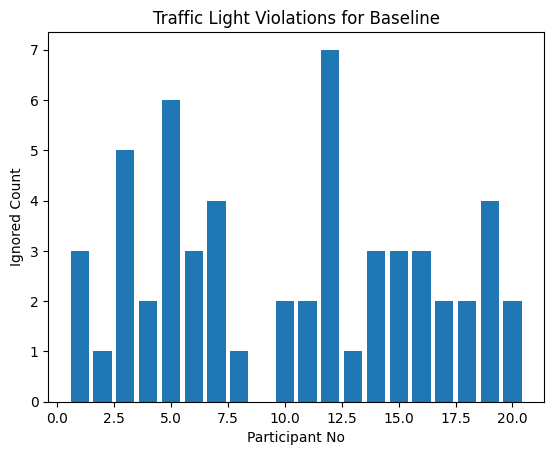

In [116]:
violations_light = df_phase1["event"].str.contains("RED_LIGHT_VIOLATION", na=False)

# count violations per participant
light_counts1df_phase1 = (
    df_phase1[violations_light]       # filter rows
    .groupby("participant_no")       # group by participant
    .size()                          # count rows
)

light_counts1df_phase1 = light_counts1df_phase1.reindex(range(1, 21), fill_value=0)

print(light_counts1df_phase1)

plt.bar(light_counts1df_phase1.index, light_counts1df_phase1.values)

plt.xlabel("Participant No")
plt.ylabel("Ignored Count")
plt.title("Traffic Light Violations for Baseline")

plt.show()

participant_no
1     3
2     3
3     3
4     4
5     3
6     2
7     3
8     3
9     1
10    1
11    1
12    2
13    2
14    2
15    6
16    5
17    4
18    2
19    2
20    3
dtype: int64


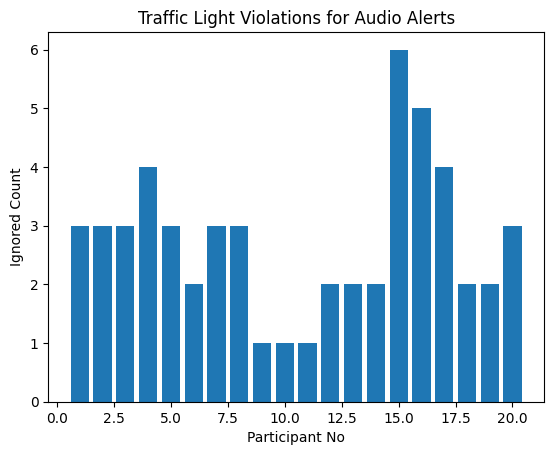

In [117]:
violations_light = df_phase2["event"].str.contains("RED_LIGHT_VIOLATION", na=False)

# count violations per participant
light_counts2 = (
    df_phase2[violations_light]       # filter rows
    .groupby("participant_no")       # group by participant
    .size()                          # count rows
)

light_counts2 = light_counts2.reindex(range(1, 21), fill_value=0)

print(light_counts2)

plt.bar(light_counts2.index, light_counts2.values)

plt.xlabel("Participant No")
plt.ylabel("Ignored Count")
plt.title("Traffic Light Violations for Audio Alerts")

plt.show()

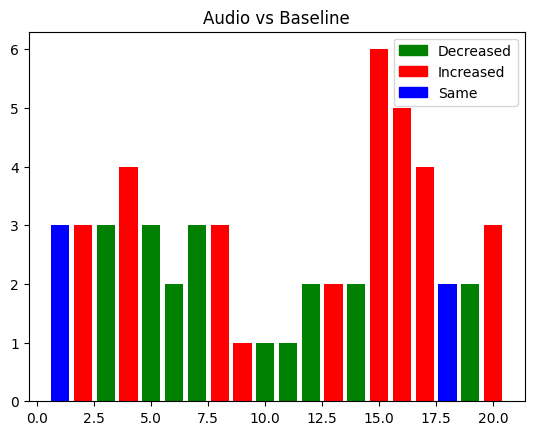

In [118]:
colors = [
    'green' if a < b else 'red' if a > b else 'blue'
    for a, b in zip(light_counts2, light_counts1df_phase1)
]

plt.bar(light_counts2.index, light_counts2.values, color=colors)

green_patch = mpatches.Patch(color='green', label='Decreased')
red_patch = mpatches.Patch(color='red', label='Increased')
blue_patch = mpatches.Patch(color='blue', label='Same')

plt.legend(handles=[green_patch, red_patch, blue_patch])
plt.title("Audio vs Baseline")
plt.show()

participant_no
1     2
2     6
3     6
4     3
5     3
6     3
7     5
8     0
9     2
10    7
11    3
12    7
13    7
14    9
15    3
16    5
17    6
18    2
19    3
20    4
dtype: int64


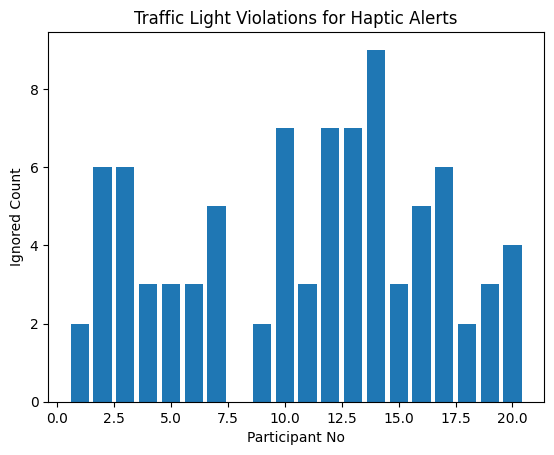

In [119]:
violations_light = df_phase3["event"].str.contains("RED_LIGHT_VIOLATION", na=False)

# count violations per participant
light_counts3 = (
    df_phase3[violations_light]       # filter rows
    .groupby("participant_no")       # group by participant
    .size()                          # count rows
)

light_counts3 = light_counts3.reindex(range(1, 21), fill_value=0)

print(light_counts3)

plt.bar(light_counts3.index, light_counts3.values)

plt.xlabel("Participant No")
plt.ylabel("Ignored Count")
plt.title("Traffic Light Violations for Haptic Alerts")

plt.show()

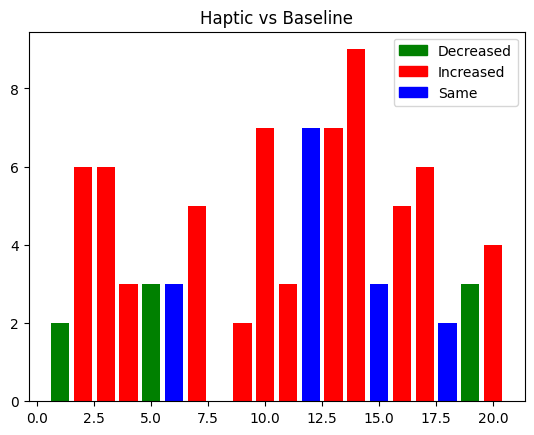

In [120]:
colors = [
    'green' if a < b else 'red' if a > b else 'blue'
    for a, b in zip(light_counts3, light_counts1df_phase1)
]

plt.bar(light_counts3.index, light_counts3.values, color=colors)

green_patch = mpatches.Patch(color='green', label='Decreased')
red_patch = mpatches.Patch(color='red', label='Increased')
blue_patch = mpatches.Patch(color='blue', label='Same')

plt.legend(handles=[green_patch, red_patch, blue_patch])
plt.title("Haptic vs Baseline")
plt.show()

participant_no
1      5
2      4
3      5
4      3
5      9
6      6
7      2
8      9
9      0
10     1
11     2
12     3
13     3
14     4
15     0
16    10
17     3
18     2
19     4
20     4
dtype: int64


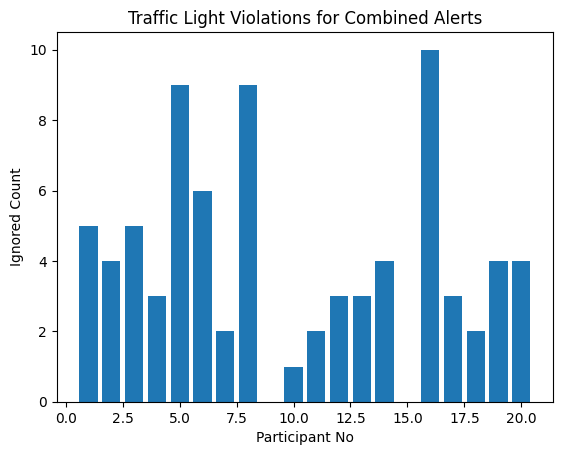

In [121]:
violations_light = df_phase4["event"].str.contains("RED_LIGHT_VIOLATION", na=False)

# count violations per participant
light_counts4 = (
    df_phase4[violations_light]       # filter rows
    .groupby("participant_no")       # group by participant
    .size()                          # count rows
)

light_counts4 = light_counts4.reindex(range(1, 21), fill_value=0)

print(light_counts4)

plt.bar(light_counts4.index, light_counts4.values)

plt.xlabel("Participant No")
plt.ylabel("Ignored Count")
plt.title("Traffic Light Violations for Combined Alerts")

plt.show()

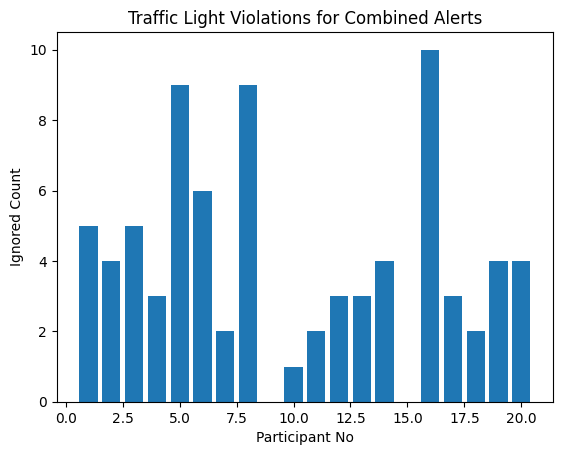

In [122]:
plt.bar(light_counts4.index, light_counts4.values)

plt.xlabel("Participant No")
plt.ylabel("Ignored Count")
plt.title("Traffic Light Violations for Combined Alerts")

plt.show()

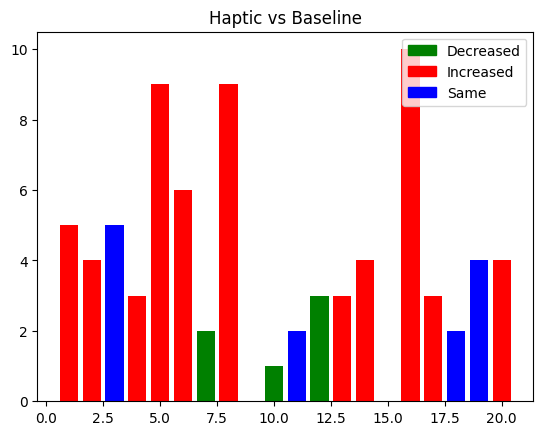

In [123]:
colors = [
    'green' if a < b else 'red' if a > b else 'blue'
    for a, b in zip(light_counts4, light_counts1df_phase1)
]

plt.bar(light_counts4.index, light_counts4.values, color=colors)

green_patch = mpatches.Patch(color='green', label='Decreased')
red_patch = mpatches.Patch(color='red', label='Increased')
blue_patch = mpatches.Patch(color='blue', label='Same')

plt.legend(handles=[green_patch, red_patch, blue_patch])
plt.title("Haptic vs Baseline")
plt.show()